<a href="https://www.kaggle.com/code/sonawanelalitsunil/monthly-spending-trends-jan-20-sep-25-ml-100?scriptVersionId=270905104" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/monthly-spending-for-eda/monthly_spending_dataset_2020_2025.csv
/kaggle/input/monthly-spending-for-eda/monthly_spending_dataset_2020_2025.xlsx


## Title: Monthly Spending Trends (Jan 2020 – Sep 2025)

## Description:
This dataset captures detailed monthly spending patterns in Indian Rupees (₹) from January 2020 to September 2025. It reflects variations in consumer expenditure over time, enabling trend analysis, forecasting, and correlation studies with key economic or lifestyle factors. Ideal for time-series modeling, budgeting insights, and financial behavior analysis across different periods.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/monthly-spending-for-eda/monthly_spending_dataset_2020_2025.csv")

In [3]:
df.head()

,Month,Groceries (₹),Rent (₹),Transportation (₹),Gym (₹),Utilities (₹),Healthcare (₹),Investments (₹),Savings (₹),EMI/Loans (₹),Dining & Entertainment (₹),Shopping & Wants (₹),Total Expenditure (₹),Income (₹)
0,2020-01-01,4860,10000,2595,888,1520,1930,4311,4232,0,3138,1121,30363,40000
1,2020-02-01,6135,10000,2371,851,1630,1923,5939,7329,0,3185,2332,34366,40000
2,2020-03-01,6853,10000,2715,1143,1776,1185,4700,3625,0,2684,1459,32515,36000
3,2020-04-01,6904,10000,2582,869,1975,1274,4420,6426,0,2475,2806,33305,36000
4,2020-05-01,4562,10000,3028,830,1984,1631,4410,3647,0,2146,1020,29611,36000


In [4]:
df.tail()

,Month,Groceries (₹),Rent (₹),Transportation (₹),Gym (₹),Utilities (₹),Healthcare (₹),Investments (₹),Savings (₹),EMI/Loans (₹),Dining & Entertainment (₹),Shopping & Wants (₹),Total Expenditure (₹),Income (₹)
64,2025-05-01,6850,13000,1643,1072,1568,2890,8171,7761,0,1895,2048,39137,64000
65,2025-06-01,7167,13000,2562,808,2192,2068,6584,9916,0,2565,2209,39155,64000
66,2025-07-01,7156,13000,2738,920,1734,2686,8601,11756,0,2250,1587,40672,64000
67,2025-08-01,8960,13000,2753,706,1673,2776,6632,11659,0,3176,2191,41867,64000
68,2025-09-01,8681,13000,3040,728,1664,2717,8260,11924,0,2945,1338,42373,64000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69 entries, 0 to 68
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Month                       69 non-null     object
 1   Groceries (₹)               69 non-null     int64 
 2   Rent (₹)                    69 non-null     int64 
 3   Transportation (₹)          69 non-null     int64 
 4   Gym (₹)                     69 non-null     int64 
 5   Utilities (₹)               69 non-null     int64 
 6   Healthcare (₹)              69 non-null     int64 
 7   Investments (₹)             69 non-null     int64 
 8   Savings (₹)                 69 non-null     int64 
 9   EMI/Loans (₹)               69 non-null     int64 
 10  Dining & Entertainment (₹)  69 non-null     int64 
 11  Shopping & Wants (₹)        69 non-null     int64 
 12  Total Expenditure (₹)       69 non-null     int64 
 13  Income (₹)                  69 non-null     int64 
d

In [6]:
df.describe()

,Groceries (₹),Rent (₹),Transportation (₹),Gym (₹),Utilities (₹),Healthcare (₹),Investments (₹),Savings (₹),EMI/Loans (₹),Dining & Entertainment (₹),Shopping & Wants (₹),Total Expenditure (₹),Income (₹)
count,69.000000,69.00000,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000
mean,6286.913043,11000.00000,2569.260870,967.768116,1978.898551,1750.420290,6317.000000,7612.550725,1130.434783,2739.594203,1963.753623,36704.043478,50446.376812
std,1233.330400,1424.57424,577.704373,149.508523,304.688228,577.078173,1459.367671,2257.266674,2363.403848,679.530641,578.126803,5843.735745,10268.750135
min,4154.000000,10000.00000,1501.000000,700.000000,1514.000000,837.000000,3952.000000,3625.000000,0.000000,1501.000000,1020.000000,28791.000000,36000.000000
25%,5158.000000,10000.00000,2095.000000,851.000000,1683.000000,1289.000000,5161.000000,6072.000000,0.000000,2146.000000,1470.000000,32829.000000,43200.000000
50%,6368.000000,10000.00000,2604.000000,1001.000000,1980.000000,1635.000000,6255.000000,7329.000000,0.000000,2743.000000,1902.000000,34111.000000,48000.000000
75%,6931.000000,13000.00000,3035.000000,1084.000000,2240.000000,2068.000000,7089.000000,9430.000000,0.000000,3185.000000,2369.000000,40672.000000,64000.000000
max,8983.000000,13000.00000,3482.000000,1196.000000,2471.000000,2958.000000,9496.000000,12074.000000,6000.000000,3991.000000,2981.000000,49167.000000,64000.000000


In [7]:
df.isnull().sum()

Month                         0
Groceries (₹)                 0
Rent (₹)                      0
Transportation (₹)            0
Gym (₹)                       0
Utilities (₹)                 0
Healthcare (₹)                0
Investments (₹)               0
Savings (₹)                   0
EMI/Loans (₹)                 0
Dining & Entertainment (₹)    0
Shopping & Wants (₹)          0
Total Expenditure (₹)         0
Income (₹)                    0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.describe().loc[['mean','min','max']]

,Groceries (₹),Rent (₹),Transportation (₹),Gym (₹),Utilities (₹),Healthcare (₹),Investments (₹),Savings (₹),EMI/Loans (₹),Dining & Entertainment (₹),Shopping & Wants (₹),Total Expenditure (₹),Income (₹)
mean,6286.913043,11000.0,2569.26087,967.768116,1978.898551,1750.42029,6317.0,7612.550725,1130.434783,2739.594203,1963.753623,36704.043478,50446.376812
min,4154.000000,10000.0,1501.00000,700.000000,1514.000000,837.00000,3952.0,3625.000000,0.000000,1501.000000,1020.000000,28791.000000,36000.000000
max,8983.000000,13000.0,3482.00000,1196.000000,2471.000000,2958.00000,9496.0,12074.000000,6000.000000,3991.000000,2981.000000,49167.000000,64000.000000


In [10]:
df.nunique()

Month                         69
Groceries (₹)                 69
Rent (₹)                       2
Transportation (₹)            68
Gym (₹)                       66
Utilities (₹)                 68
Healthcare (₹)                68
Investments (₹)               69
Savings (₹)                   69
EMI/Loans (₹)                  2
Dining & Entertainment (₹)    65
Shopping & Wants (₹)          68
Total Expenditure (₹)         69
Income (₹)                     6
dtype: int64

In [11]:
df.shape

(69, 14)

In [12]:
df.dtypes

Month                         object
Groceries (₹)                  int64
Rent (₹)                       int64
Transportation (₹)             int64
Gym (₹)                        int64
Utilities (₹)                  int64
Healthcare (₹)                 int64
Investments (₹)                int64
Savings (₹)                    int64
EMI/Loans (₹)                  int64
Dining & Entertainment (₹)     int64
Shopping & Wants (₹)           int64
Total Expenditure (₹)          int64
Income (₹)                     int64
dtype: object

In [13]:
df.columns

Index(['Month', 'Groceries (₹)', 'Rent (₹)', 'Transportation (₹)', 'Gym (₹)',
       'Utilities (₹)', 'Healthcare (₹)', 'Investments (₹)', 'Savings (₹)',
       'EMI/Loans (₹)', 'Dining & Entertainment (₹)', 'Shopping & Wants (₹)',
       'Total Expenditure (₹)', 'Income (₹)'],
      dtype='object')

## Data visualizations

In [14]:
import calendar
from matplotlib.ticker import FuncFormatter

In [15]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Blues_d")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12


In [16]:
df['Month'] = pd.to_datetime(df['Month'])
df['Year'] = df['Month'].dt.year
df['Month_Name'] = df['Month'].dt.strftime('%b')

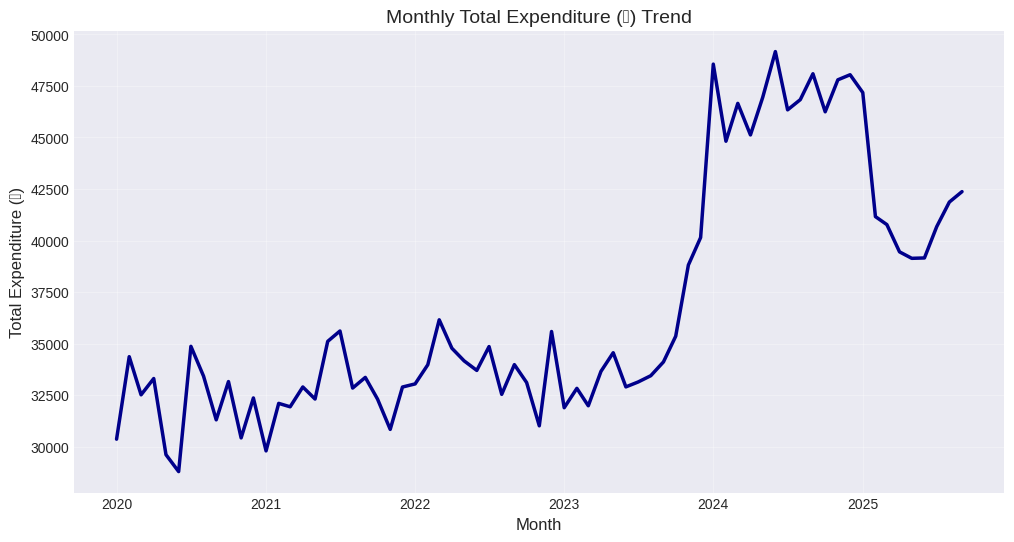

In [17]:
plt.figure(figsize=(12,6))
plt.plot(df['Month'], df['Total Expenditure (₹)'], color='darkblue', linewidth=2.5)
plt.title('Monthly Total Expenditure (₹) Trend')
plt.xlabel('Month')
plt.ylabel('Total Expenditure (₹)')
plt.grid(True, alpha=0.3)
plt.show()

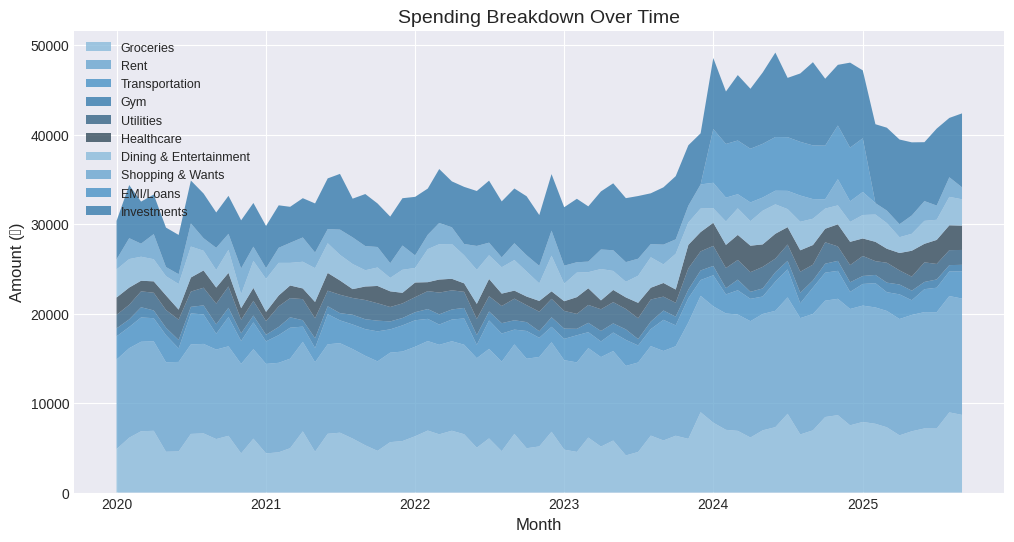

In [18]:
spend_cols = ['Groceries (₹)', 'Rent (₹)', 'Transportation (₹)', 'Gym (₹)',
              'Utilities (₹)', 'Healthcare (₹)', 'Dining & Entertainment (₹)',
              'Shopping & Wants (₹)', 'EMI/Loans (₹)', 'Investments (₹)']

plt.figure(figsize=(12,6))
plt.stackplot(df['Month'], [df[col] for col in spend_cols],
              labels=[col.replace(' (₹)', '') for col in spend_cols],
              alpha=0.8)
plt.legend(loc='upper left', fontsize=9)
plt.title('Spending Breakdown Over Time')
plt.xlabel('Month')
plt.ylabel('Amount (₹)')
plt.show()


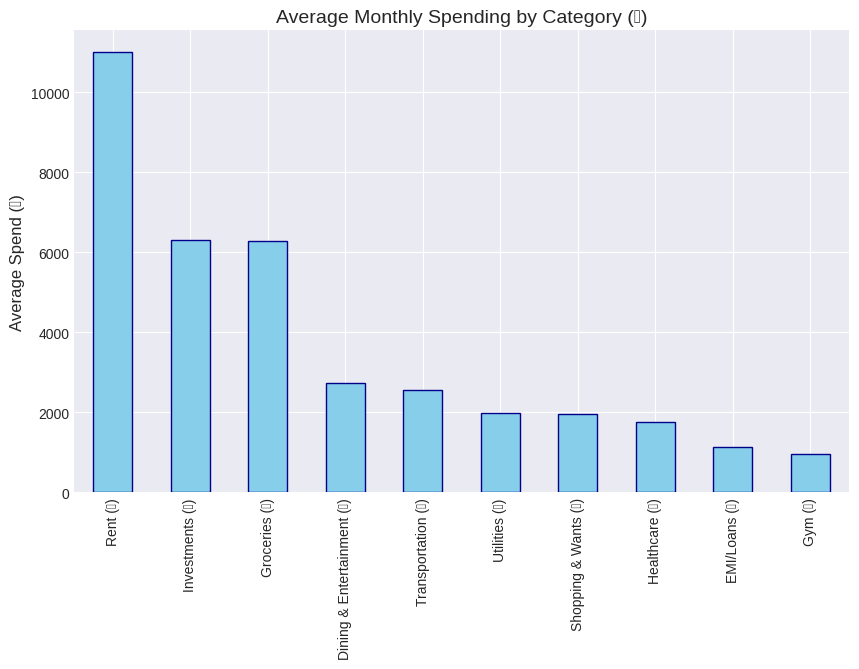

In [19]:
avg_spending = df[spend_cols].mean().sort_values(ascending=False)
avg_spending.plot(kind='bar', color='skyblue', edgecolor='darkblue')
plt.title('Average Monthly Spending by Category (₹)')
plt.ylabel('Average Spend (₹)')
plt.show()

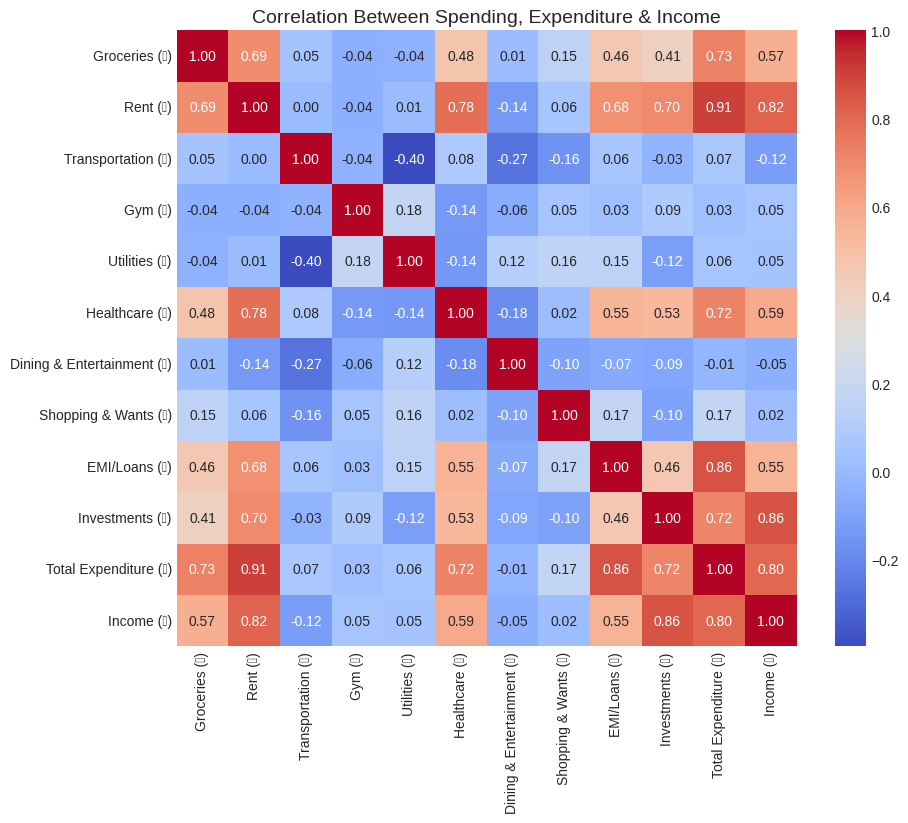

In [20]:
plt.figure(figsize=(10,8))
corr = df[spend_cols + ['Total Expenditure (₹)', 'Income (₹)']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Between Spending, Expenditure & Income')
plt.show()

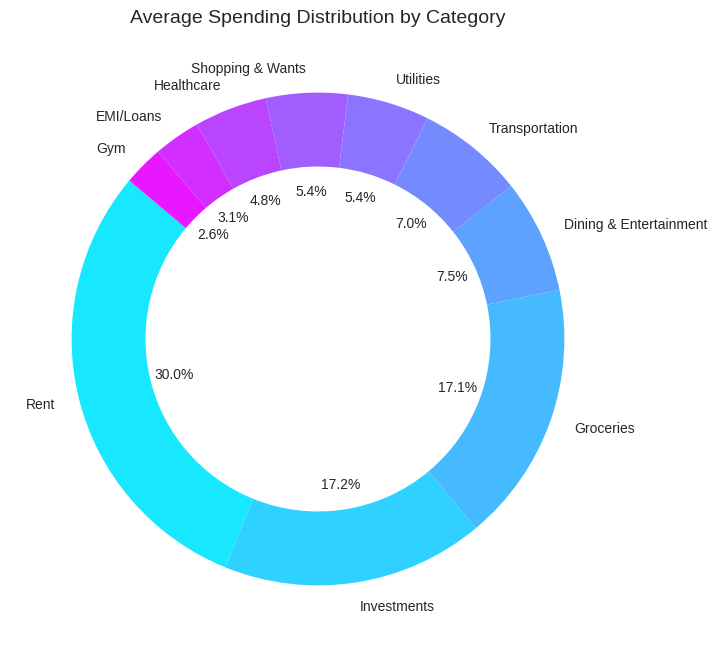

In [21]:
colors = sns.color_palette("cool", len(spend_cols))
fig, ax = plt.subplots(figsize=(8,8))
ax.pie(avg_spending, labels=[col.replace(' (₹)', '') for col in avg_spending.index],
       autopct='%1.1f%%', startangle=140, colors=colors, wedgeprops={'width':0.3})
plt.title('Average Spending Distribution by Category')
plt.show()


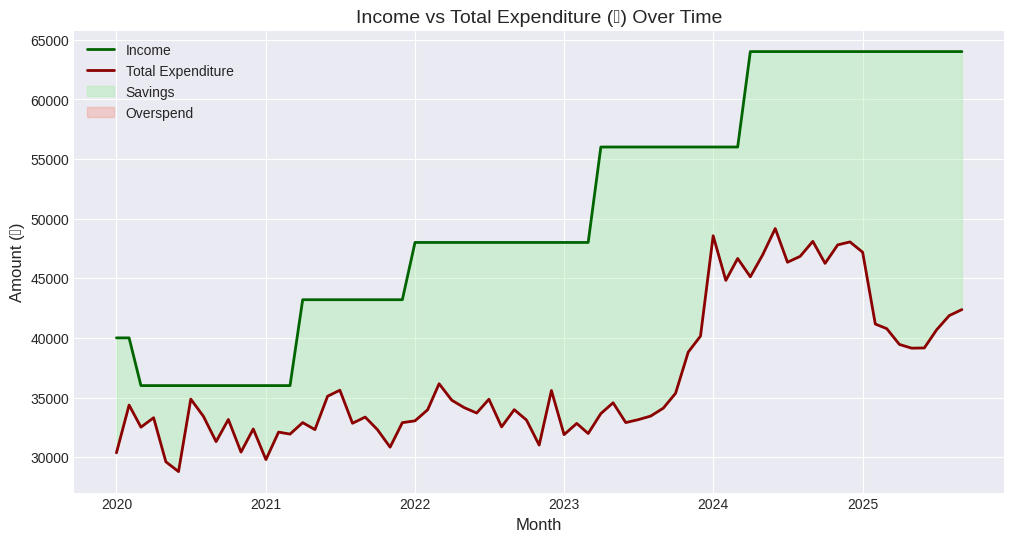

In [22]:
plt.figure(figsize=(12,6))
plt.plot(df['Month'], df['Income (₹)'], label='Income', color='darkgreen', linewidth=2)
plt.plot(df['Month'], df['Total Expenditure (₹)'], label='Total Expenditure', color='darkred', linewidth=2)
plt.fill_between(df['Month'], df['Income (₹)'], df['Total Expenditure (₹)'],
                 where=(df['Income (₹)'] > df['Total Expenditure (₹)']),
                 interpolate=True, color='lightgreen', alpha=0.3, label='Savings')
plt.fill_between(df['Month'], df['Income (₹)'], df['Total Expenditure (₹)'],
                 where=(df['Income (₹)'] < df['Total Expenditure (₹)']),
                 interpolate=True, color='salmon', alpha=0.3, label='Overspend')
plt.legend()
plt.title('Income vs Total Expenditure (₹) Over Time')
plt.xlabel('Month')
plt.ylabel('Amount (₹)')
plt.show()

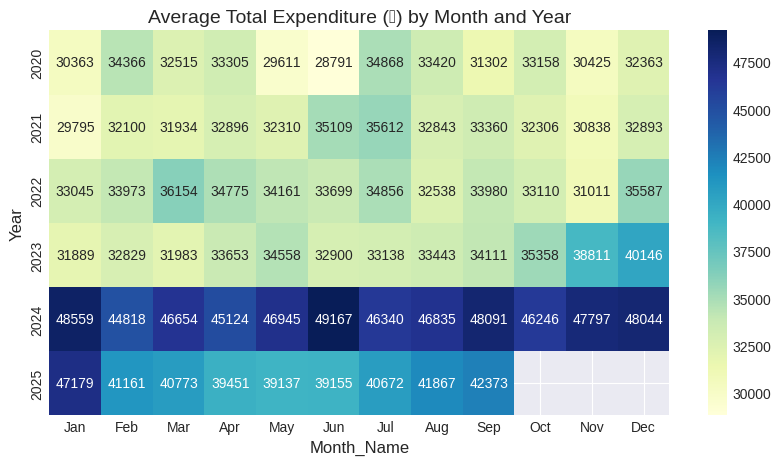

In [23]:
pivot = df.pivot_table(index='Year', columns='Month_Name', values='Total Expenditure (₹)', aggfunc='mean')
pivot = pivot.reindex(columns=list(calendar.month_abbr)[1:])
plt.figure(figsize=(10,5))
sns.heatmap(pivot, cmap='YlGnBu', annot=True, fmt='.0f')
plt.title('Average Total Expenditure (₹) by Month and Year')
plt.show()


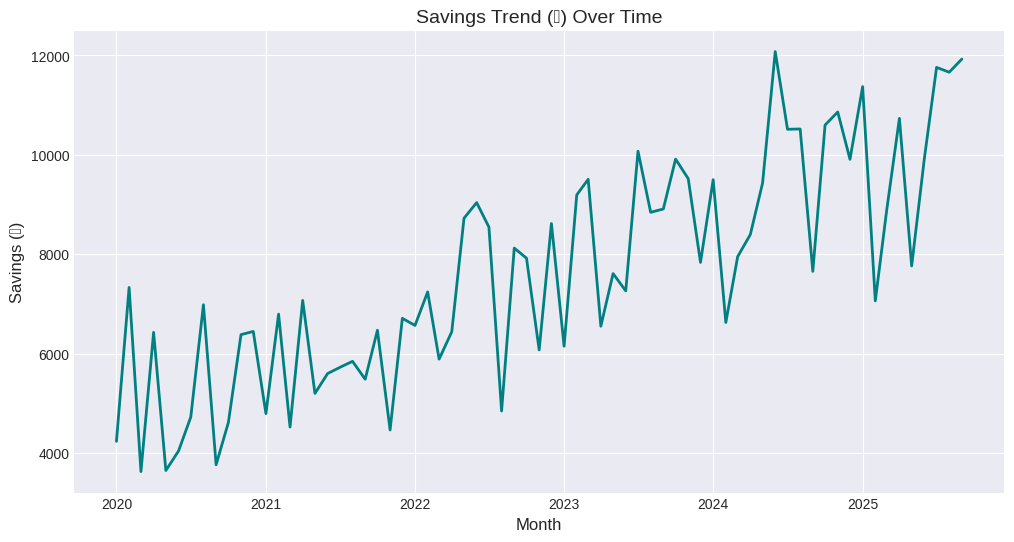

In [24]:
plt.figure(figsize=(12,6))
sns.lineplot(x='Month', y='Savings (₹)', data=df, color='teal', linewidth=2)
plt.title('Savings Trend (₹) Over Time')
plt.xlabel('Month')
plt.ylabel('Savings (₹)')
plt.show()


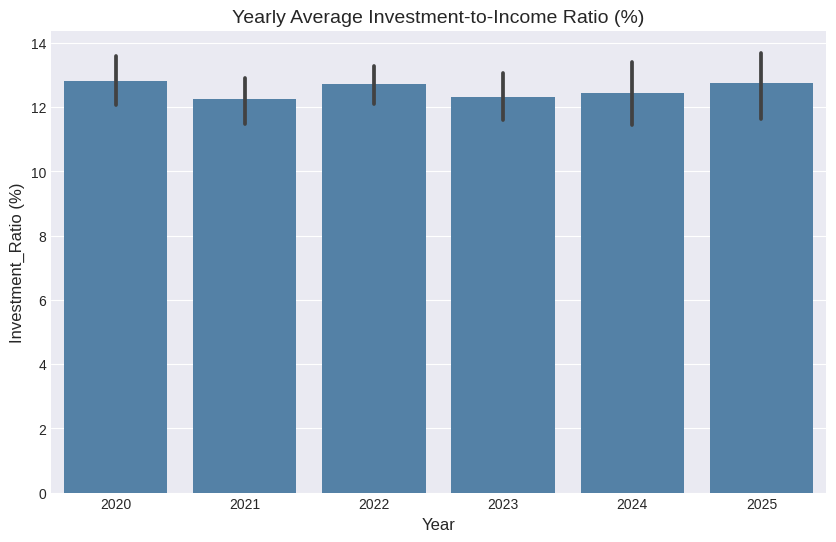

In [25]:
df['Investment_Ratio (%)'] = (df['Investments (₹)'] / df['Income (₹)']) * 100
plt.figure(figsize=(10,6))
sns.barplot(x='Year', y='Investment_Ratio (%)', data=df, color='steelblue')
plt.title('Yearly Average Investment-to-Income Ratio (%)')
plt.show()

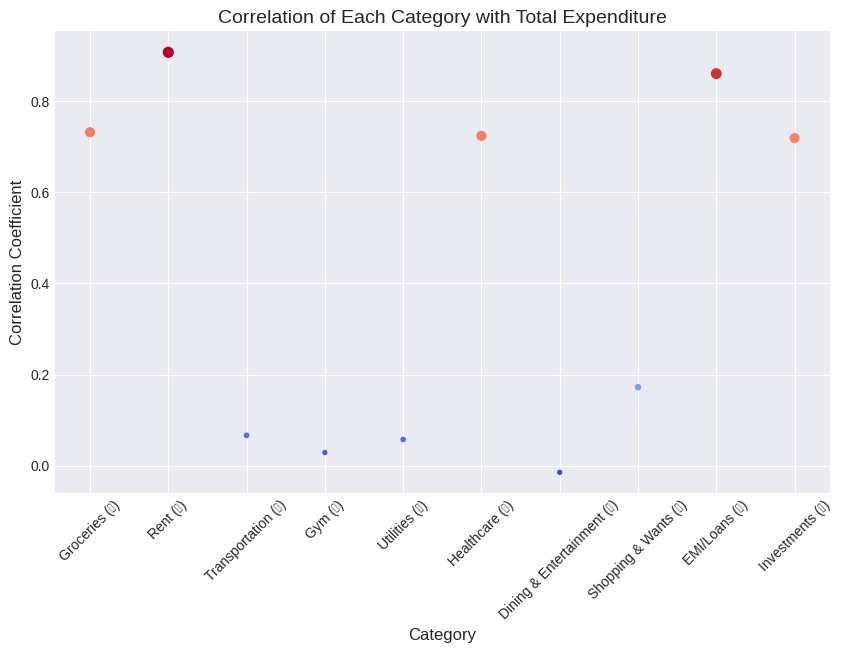

In [26]:
corr_data = corr.loc['Total Expenditure (₹)', spend_cols]
plt.figure(figsize=(10,6))
sns.scatterplot(x=spend_cols, y=corr_data.values, size=np.abs(corr_data.values)*500,
                hue=corr_data.values, palette='coolwarm', legend=False)
plt.xticks(rotation=45)
plt.title('Correlation of Each Category with Total Expenditure')
plt.ylabel('Correlation Coefficient')
plt.xlabel('Category')
plt.show()

## ML Algorithms

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor

In [28]:
df['Month'] = pd.to_datetime(df['Month'])
df['Year'] = df['Month'].dt.year
df['Month_Name'] = df['Month'].dt.month_name()

# Label Encoding categorical feature (Month_Name)
le = LabelEncoder()
df['Month_Label'] = le.fit_transform(df['Month_Name'])

In [29]:
features = ['Groceries (₹)', 'Rent (₹)', 'Transportation (₹)', 'Gym (₹)',
            'Utilities (₹)', 'Healthcare (₹)', 'Investments (₹)', 'Savings (₹)',
            'EMI/Loans (₹)', 'Dining & Entertainment (₹)', 'Shopping & Wants (₹)',
            'Income (₹)', 'Year', 'Month_Label']

target = 'Total Expenditure (₹)'

In [30]:
X = df[features]
y = df[target]


In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [33]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'Support Vector Regressor': SVR(),
    'K-Nearest Neighbors': KNeighborsRegressor(),
    'XGBoost': XGBRegressor(random_state=42, n_estimators=200)
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    results.append({
        'Model': name,
        'R² Score (%)': round(r2 * 100, 2),
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2)
    })


In [34]:
results_df = pd.DataFrame(results).sort_values(by='R² Score (%)', ascending=False)
print("🔹 Model Performance Summary:")
print(results_df)

🔹 Model Performance Summary:
                      Model  R² Score (%)      MAE     RMSE
0         Linear Regression        100.00     0.00     0.00
2          Lasso Regression        100.00     7.24     9.10
1          Ridge Regression         99.97    79.38   107.14
3             Decision Tree         93.12  1425.43  1665.32
5         Gradient Boosting         92.65  1517.28  1721.62
8                   XGBoost         91.40  1565.53  1862.11
4             Random Forest         90.16  1716.74  1992.52
7       K-Nearest Neighbors         85.02  2111.99  2458.00
6  Support Vector Regressor          0.06  4824.68  6348.68


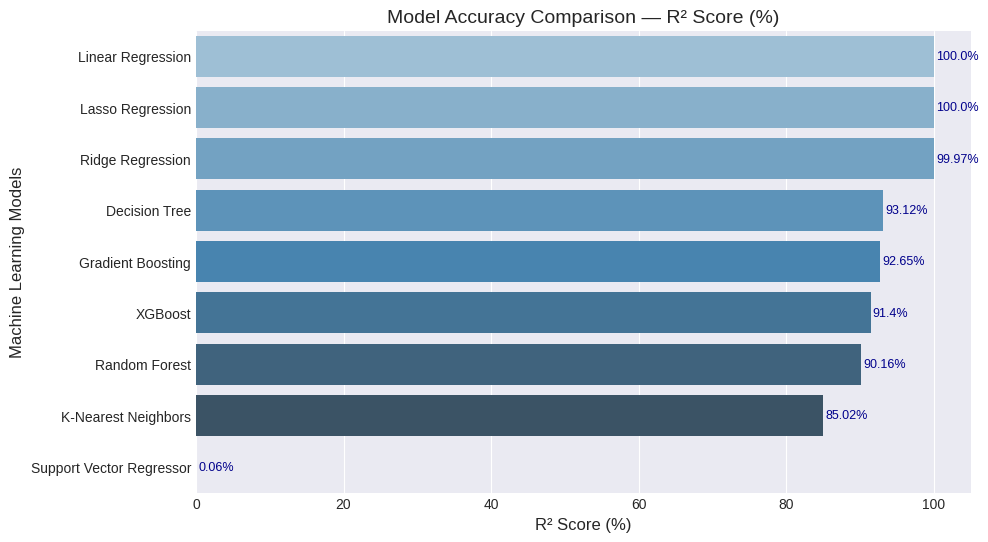

In [35]:
plt.figure(figsize=(10,6))
sns.barplot(x='R² Score (%)', y='Model', data=results_df, palette='Blues_d')
plt.title('Model Accuracy Comparison — R² Score (%)')
plt.xlabel('R² Score (%)')
plt.ylabel('Machine Learning Models')
for index, value in enumerate(results_df['R² Score (%)']):
    plt.text(value + 0.3, index, f"{value}%", va='center', fontsize=9, color='darkblue')
plt.show()

## Thank you...pls upvote!!!!